In [38]:
%matplotlib widget

In [45]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import mplcursors
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["dodgerblue", "red"])

from pre.load import fits2numpy
from pre.preprocess import preprocess_lognorm

In [40]:
synthetic_path = "../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_CNN_val_best_model_val_acc.npy"
real_path = "../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_CNN_domain_0305_best_model_val_acc.npy"
test_path = "../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_cnn_metrics_14_04_best_model_val_acc.npy"
test_fits_paths_path = "../scripts/model.ptcnn_DA_20260401-230242/test_paths_da.npy"
test_labels_path = "../scripts/model.ptcnn_DA_20260401-230242/test_labels_da.npy"

In [ ]:
X_synth = np.load(synthetic_path, allow_pickle=True)
X_real = np.load(real_path, allow_pickle=True)
X_test = np.load(test_path, allow_pickle=True)
test_fits_paths = np.load(test_fits_paths_path, allow_pickle=True)
test_labels = np.load(test_labels_path, allow_pickle=True)

assert len(X_test) == len(test_fits_paths)

X_all = np.concatenate([X_synth, X_real, X_test], axis=0)
# X_all = X_test 

reducer = umap.UMAP(
    # n_neighbors=15,
    # min_dist=0.1,
    # n_components=2,
    # metric="cosine",
    # random_state=42,
)

X_umap = reducer.fit_transform(X_all, y=test_labels)

n_synth = len(X_synth)
n_real = len(X_real)

umap_synth = X_umap[:n_synth]
umap_real = X_umap[n_synth:n_synth + n_real]
umap_test = X_umap[n_synth + n_real:]
# umap_test = X_umap

In [42]:
def load_fits_image(path):
    img = fits2numpy(path)
    img = preprocess_lognorm(img)
    return np.squeeze(img)

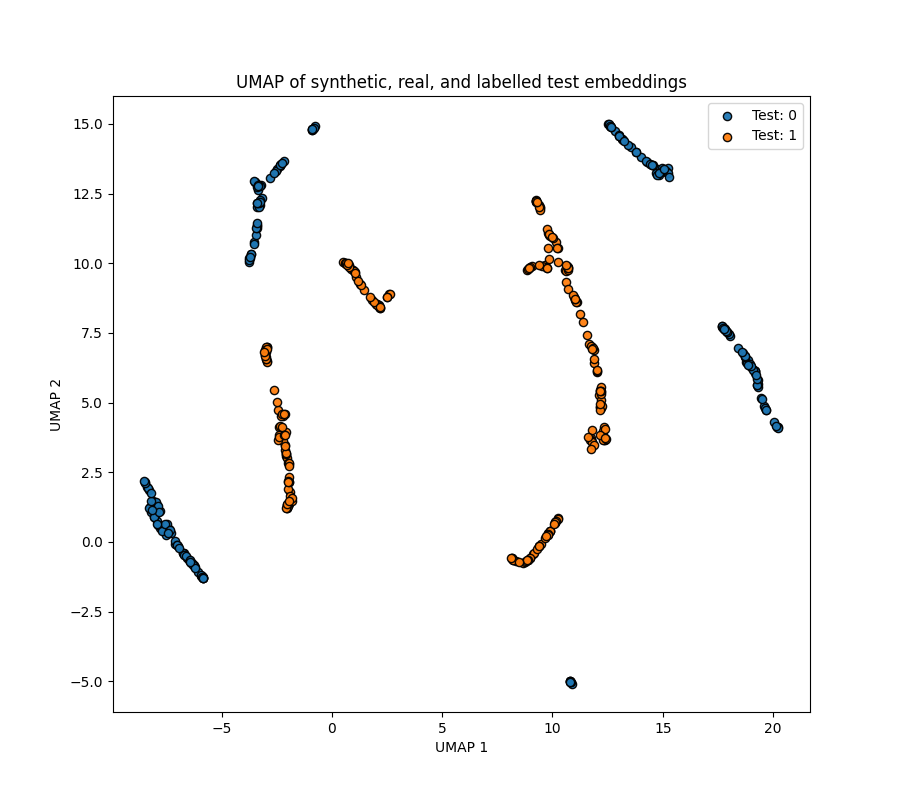

In [47]:
fig, ax = plt.subplots(figsize=(9, 8))

# ax.scatter(
#     umap_synth[:, 0],
#     umap_synth[:, 1],
#     s=4,
#     alpha=0.3,
#     label="Synthetic",
# )

# ax.scatter(
#     umap_real[:, 0],
#     umap_real[:, 1],
#     s=4,
#     alpha=0.3,
#     label="Real",
# )


assert len(X_test) == len(test_fits_paths) == len(test_labels)

test_labels = np.asarray(test_labels)
unique_labels = sorted(set(test_labels))

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# visible points with proper legend
for i, label in enumerate(unique_labels):
    mask = test_labels == label

    ax.scatter(
        umap_test[mask, 0],
        umap_test[mask, 1],
        s=35,
        alpha=0.95,
        color=colors[i % len(colors)],
        edgecolors="black",
        label=f"Test: {label}",
    )

# invisible scatter only for mplcursors;
# this preserves sel.index == index in test_fits_paths/test_labels
test_scatter = ax.scatter(
    umap_test[:, 0],
    umap_test[:, 1],
    s=35,
    alpha=0.0,
)

ax.set_title("UMAP of synthetic, real, and labelled test embeddings")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend()

annotation_box = None

cursor = mplcursors.cursor(test_scatter, hover=False)  # click mode

@cursor.connect("add")
def on_add(sel):
    global annotation_box

    if annotation_box is not None:
        annotation_box.remove()
        annotation_box = None

    idx = sel.index
    path = str(test_fits_paths[idx])
    label = test_labels[idx]

    sel.annotation.set_text(f"label: {label}\n{path}")

    img = load_fits_image(path)

    imagebox = OffsetImage(img, zoom=1.2, cmap="gray")

    annotation_box = AnnotationBbox(
        imagebox,
        (umap_test[idx, 0], umap_test[idx, 1]),
        xybox=(90, 90),
        xycoords="data",
        boxcoords="offset points",
        frameon=True,
    )

    ax.add_artist(annotation_box)
    fig.canvas.draw_idle()